**Introducción:** La municipalidad de Rosario quiere estimar un modelo del consumo energético dentro de la ciudad y le encargó este trabajo a ustedes. Para esto, les proveyó los siguientes datasets: 

## **Datos Medidos** : 

- id_edificio: Valor único de cada registro. tipo_edificio: Tipo de edificio. 

- metros_cuadrados: Metros cuadrados de la propiedad. numero_ocupantes: Número de ocupantes de la propiedad. 

- electrodomesticos: Cantidad de electrodomesticos/maquinaria en uso en la propiedad. temperatura_media: Temperatura media del día de la medición. 

- dia_semana: Día de la semana cuando se realizó la medición. consumo_energia: Consumo energético de la propiedad en KWh. 

## **Datos del barrio** : 

id_edificio: Valor único de cada registro. barrio: Barrio donde se encuentra la propiedad. 

## PARTE I 

**Ejercicio 1.** Importe ambos datasets y realice cualquier tarea de limpieza y adecuación de los mismos que considere necesaria para su posterior análisis. Indicar la cantidad de registros que tiene cada uno de los datasets. 



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
barrio=pd.read_csv('barrio_edificio.csv')
barrio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_edificio  1000 non-null   int64 
 1   barrio       1000 non-null   object
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
barrio

,id_edificio,barrio
0,0,Norte
1,1,Norte
2,2,Norte
3,3,Centro
4,4,Oeste
...,...,...
995,995,Norte
996,996,Sur
997,997,Norte
998,998,Oeste


In [6]:
consumo=pd.read_csv('consumo_edificio.csv')
consumo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_edificio        1000 non-null   int64  
 1   tipo_edificio      1000 non-null   object 
 2   numero_ocupantes   1000 non-null   int64  
 3   electrodomesticos  1000 non-null   int64  
 4   temperatura_media  1000 non-null   float64
 5   dia_semana         1000 non-null   object 
 6   consumo_energia    1000 non-null   float64
 7   metros_cuadrados   1000 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 62.6+ KB


In [7]:
consumo

,id_edificio,tipo_edificio,numero_ocupantes,electrodomesticos,temperatura_media,dia_semana,consumo_energia,metros_cuadrados
0,0,Residencial,76,10,29.84,habil,3264.235229,-800.581029
1,1,Comercial,66,45,16.72,fin_de_semana,6486.624735,4076.513979
2,2,Industrial,37,17,14.30,habil,4276.656672,2706.630060
3,3,Residencial,14,41,32.82,habil,3209.388291,805.112632
4,4,Comercial,26,18,11.92,habil,3266.871261,1175.467038
...,...,...,...,...,...,...,...,...
995,995,Residencial,68,44,23.95,habil,3318.267025,1499.865640
996,996,Industrial,7,22,14.67,fin_de_semana,2558.830350,752.823635
997,997,Comercial,88,20,32.18,habil,5167.923798,3932.952963
998,998,Residencial,67,37,16.48,fin_de_semana,2460.767051,551.695329


In [12]:
print(consumo.describe())

       id_edificio  numero_ocupantes  electrodomesticos  temperatura_media  \
count  1000.000000       1000.000000        1000.000000        1000.000000   
mean    499.500000         48.372000          25.606000          22.611390   
std     288.819436         29.061972          14.105166           7.139943   
min       0.000000          1.000000           1.000000          10.050000   
25%     249.750000         22.000000          13.000000          16.475000   
50%     499.500000         47.000000          26.000000          22.815000   
75%     749.250000         73.250000          38.000000          28.850000   
max     999.000000         99.000000          49.000000          34.990000   

       consumo_energia  metros_cuadrados  
count      1000.000000       1000.000000  
mean       4096.041892       2365.814826  
std        1034.996210       1550.636362  
min        1302.748860      -1972.593977  
25%        3404.320013       1193.154377  
50%        4080.743931       2327.84094

In [13]:
consumo['metros_cuadrados']=consumo['metros_cuadrados'].abs()
consumo.describe()

,id_edificio,numero_ocupantes,electrodomesticos,temperatura_media,consumo_energia,metros_cuadrados
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,48.372000,25.606000,22.611390,4096.041892,2423.628682
std,288.819436,29.061972,14.105166,7.139943,1034.996210,1458.526570
min,0.000000,1.000000,1.000000,10.050000,1302.748860,1.559314
25%,249.750000,22.000000,13.000000,16.475000,3404.320013,1227.341568
50%,499.500000,47.000000,26.000000,22.815000,4080.743931,2327.840943
75%,749.250000,73.250000,38.000000,28.850000,4819.304458,3582.601753
max,999.000000,99.000000,49.000000,34.990000,7097.948430,6823.252618


In [14]:
print(f'Barrio tiene {len(barrio)} regristros y Consumo tiene {len(consumo)} registros')

Barrio tiene 1000 regristros y Consumo tiene 1000 registros


In [15]:
# Combinar ambos datasets mediante un inner join usando 'id_edificio'
df_completo = pd.merge(consumo, barrio, on='id_edificio', how='inner')

**Ejercicio 2.** Muestre la distribución del consumo de energía por tipo de edificio. Explique el resultado obtenido a su clienta que no tiene una formación técnica. 

In [22]:
df_completo.groupby('tipo_edificio')['consumo_energia'].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_edificio,,,,,,,,
Comercial,336.0,4080.648500,906.441089,1892.571674,3446.539044,4062.964616,4733.155685,6778.109531
Industrial,317.0,4646.673082,958.993754,2252.465630,3969.865244,4671.891540,5357.042065,7097.948430
Residencial,347.0,3607.921121,969.794447,1302.748860,2922.566732,3636.989283,4295.437012,5927.355959


C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_3088\3132050025.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_completo,x='tipo_edificio',y='consumo_energia',palette='Set1')


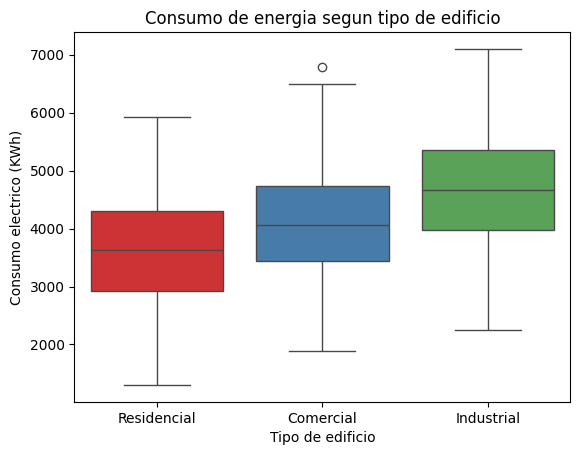

In [23]:
sns.boxplot(data=df_completo,x='tipo_edificio',y='consumo_energia',palette='Set1')
plt.title('Consumo de energia segun tipo de edificio')
plt.xlabel('Tipo de edificio')
plt.ylabel('Consumo electrico (KWh)')
plt.show()

**Ejercicio 3.** . Su clienta está preocupada porque alguien le dijo que los datos de temperatura están sesgados. Podría verificar esta información y escribir un mensaje para enviarle a su clienta? 

Para saber si estan sesgado calculamos el coeficiente de asimetria(skewness) de temperatura media. Si da cercano a cero es que no hay sesgo

In [24]:
asimetria_temp = df_completo['temperatura_media'].skew()
print(f"Coeficiente de asimetría (skewness) de la temperatura: {asimetria_temp:.4f}")

Coeficiente de asimetría (skewness) de la temperatura: -0.0404


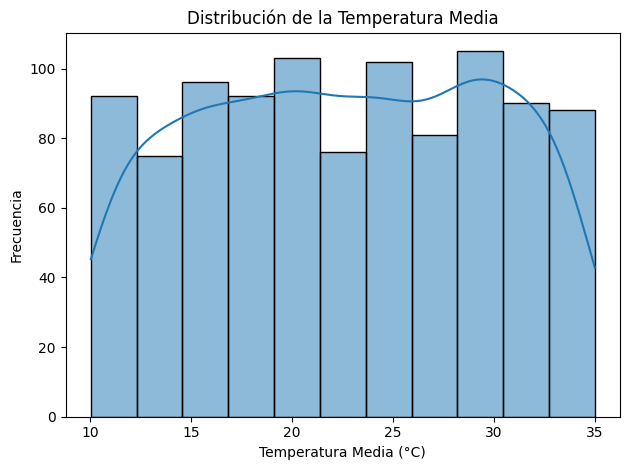

In [27]:
sns.histplot(df_completo['temperatura_media'],kde=True)
plt.title('Distribución de la Temperatura Media')
plt.xlabel('Temperatura Media (°C)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Ejercicio 4.** Realice un gráfico que nos muestre como varía el consumo de energía con respecto al número de ocupantes que tiene la propiedad. Describa esta relación para su clienta. 

In [28]:
correlacion_ocupantes = df_completo['consumo_energia'].corr(df_completo['numero_ocupantes'])
print(f"Correlación lineal entre consumo y ocupantes: {correlacion_ocupantes:.4f}")

Correlación lineal entre consumo y ocupantes: 0.3165


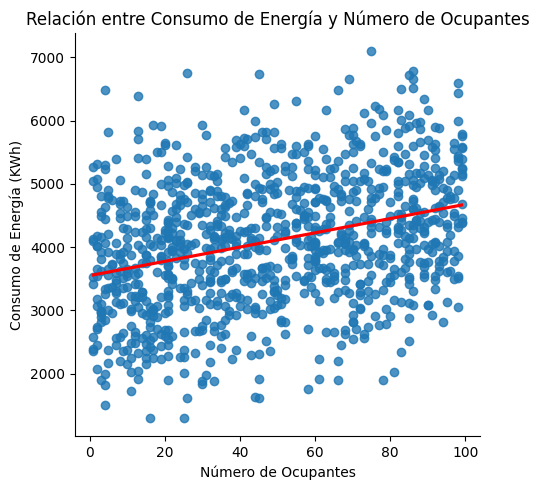

In [34]:
sns.lmplot(x='numero_ocupantes', y='consumo_energia', data=df_completo, line_kws={'color':'red'},ci=None)
plt.title('Relación entre Consumo de Energía y Número de Ocupantes')
plt.xlabel('Número de Ocupantes')
plt.ylabel('Consumo de Energía (KWh)')
plt.tight_layout()
plt.show()

-----------------------------------------

## Parte II 

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal que permita predecir el consumo energético de un edificio de la ciudad. 

**Ejercicio 1** Ajuste un modelo para predecir el consumo de energía utilizando la totalidad de las variables presentadas. Se solicita que las variables explicativas, exceptos las dummies, estén estandarizadas de la siguiente forma: 

**==> picture [73 x 28] intentionally omitted <==**

Donde: 

- Z_i es el valor estandarizado 

- X_i es la valor de la variable original 

- X_barra es la media de la muestra de X 

- s es la desviación estándar de la muestra de X 

### NO HACER POR SER UNIDAD 5

**Ejercicio 2** En base al modelo anterior, quitar todas las variables que no sean estadísticamente significativas. Consideramos que estadísticamente significativo implica que la probabilidad que el coeficiente estimado sea cero es menor al 5%. 

In [37]:
modelo=smf.ols('consumo_energia ~ numero_ocupantes + electrodomesticos + temperatura_media + metros_cuadrados + C(tipo_edificio) + C(dia_semana) + C(barrio)',data=df_completo).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        consumo_energia   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     284.0
Date:               sá., 06 jun. 2026   Prob (F-statistic):          1.42e-282
Time:                        23:23:33   Log-Likelihood:                -7683.7
No. Observations:                1000   AIC:                         1.539e+04
Df Residuals:                     989   BIC:                         1.544e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [38]:
#Saco los dias_semana que no es signficativo
modelo2=smf.ols('consumo_energia ~ numero_ocupantes + electrodomesticos + temperatura_media + metros_cuadrados + tipo_edificio + barrio',data=df_completo).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:        consumo_energia   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     315.2
Date:               sá., 06 jun. 2026   Prob (F-statistic):          1.73e-283
Time:                        23:32:17   Log-Likelihood:                -7684.5
No. Observations:                1000   AIC:                         1.539e+04
Df Residuals:                     990   BIC:                         1.544e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

La ecuacion de la ecuacion lineal multiple es:

* $\hat{y}=2622.305+483.4983*x_{industrial}-453.7035*x_{residencial}-358.3597*x_{Norte}-532.1911*x_{Oeste}-707.3452*x_{Sur}+9.5272*x_{ocupantes}+20.3552*x_{electrodomesticos}-5.0535*x_{temperatura}+0.4199*x_{m2}$

**Ejercicio 3** La propiedad de la empresa **"AlfajoresRicos"** tiene un consumo sospechosamente bajo de 3000 KWh. Su clienta le pide que use el modelo para estimar el consumo de la propiedad y si el consumo que usted encuentra es 20% mayor 3000 KWh, deberá informarle a su clienta para que inicie una investigación a **"AlfajoresRicos"** . 

Características de la propiedad y día de medición: 

|**variable**|**valor**|**valor estandarizado**|
|---|---|---|
|tipo_edifcio|Industrial|NA|
|numero_ocupantes|26|-0.766|
|electrodomesticos|19|-0.464|
|temperatura_media|20|-0.374|
|dia_semana|habil|NA|
|metros_cuadrados|5000|1.736|
|barrio|Centro|NA|

In [40]:
prediccion=2622.305+483.4983*1-453.7035*0-358.3597*0-532.1911*0-707.3452*0+9.5272*26+20.3552*19-5.0535*20+0.4199*5000
print(f'El consumo predicho de la propiedad de Alfajores Ricos es de {round(prediccion,2)} kw/h')

El consumo predicho de la propiedad de Alfajores Ricos es de 5738.69 kw/h





**Ejercicio 4** Cual es la diferencia estimada en el consumo energético entre dos locales comerciales idénticos pero uno está en el Centro y el otro en zona Sur. 

In [46]:
prediccion_centro=2622.305+483.4983*1-453.7035*0-358.3597*0-532.1911*0-707.3452*0+9.5272*26+20.3552*19-5.0535*20+0.4199*5000
prediccion_sur=2622.305+483.4983*1-453.7035*0-358.3597*0-532.1911*0-707.3452*1+9.5272*26+20.3552*19-5.0535*20+0.4199*5000
print(f'Hay una diferencia de {round(prediccion_centro-prediccion_sur,2)} kwh mayor consumo en favor del local del centro')

Hay una diferencia de 707.35 kwh mayor consumo en favor del local del centro
